# 03 — Native LightGBM and Extensive Optuna HPO

This notebook replaces the shared XGBoost/LightGBM preprocessing experiment with a focused LightGBM workflow.

The key changes are:

- numerical missing values remain `NaN` so LightGBM can learn their optimal direction;
- categorical missing values become an explicit `__MISSING__` category;
- categorical columns are passed directly to LightGBM instead of one-hot encoding;
- a known strong fixed baseline is evaluated before optimization;
- Optuna runs a larger, persistent search with early stopping;
- tuned performance is measured with out-of-fold probabilities;
- differential evolution is retained only as an optional, honestly evaluated post-processing experiment.

The primary metric throughout is **balanced accuracy**.


## 1. Setup


In [ ]:
# Run once if needed:
# %pip install -q lightgbm optuna scipy scikit-learn

from pathlib import Path
import gc
import json
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

from IPython.display import display
from scipy.optimize import differential_evolution
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
TARGET = "health_condition"
ID_COL = "id"
N_CLASSES = 3
N_TRIALS = 120
N_OOF_FOLDS = 3
N_JOBS = -1

DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
PROJECT_DIR = DATA_DIR.parent
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
SUBMISSION_DIR = PROJECT_DIR / "submissions"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

STUDY_NAME = "lightgbm_native_balanced_accuracy_v1"
STORAGE_URL = f"sqlite:///{(ARTIFACT_DIR / 'lightgbm_optuna.db').resolve().as_posix()}"
print("Optuna storage:", STORAGE_URL)


Optuna storage: sqlite:///C:/Users/chris/Desktop/Kaggle/Predicting Student Health Risk/artifacts/lightgbm_optuna.db


## 2. Load data and preserve missingness


In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

X = train.drop(columns=[TARGET, ID_COL]).copy()
X_test = test.drop(columns=[ID_COL]).copy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train[TARGET])
CLASS_NAMES = label_encoder.classes_
N_CLASSES = len(CLASS_NAMES)

categorical_features = X.select_dtypes(exclude="number").columns.tolist()
numeric_features = X.select_dtypes(include="number").columns.tolist()


def prepare_native_categories(train_frame, other_frame=None):
    train_result = train_frame.copy()
    other_result = None if other_frame is None else other_frame.copy()

    for column in categorical_features:
        train_values = train_result[column].fillna("__MISSING__").astype(str)
        categories = pd.Index(train_values.unique())
        train_result[column] = pd.Categorical(train_values, categories=categories)

        if other_result is not None:
            other_values = other_result[column].fillna("__MISSING__").astype(str)
            other_result[column] = pd.Categorical(other_values, categories=categories)

    return train_result if other_result is None else (train_result, other_result)


X, X_test = prepare_native_categories(X, X_test)

print("Train:", train.shape, "| Test:", test.shape)
print("Classes:", dict(enumerate(CLASS_NAMES)))
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

class_summary = pd.DataFrame({
    "count": train[TARGET].value_counts(),
    "share": train[TARGET].value_counts(normalize=True),
})
display(class_summary.style.format({"share": "{:.2%}"}))
display(pd.DataFrame({
    "dtype": X.dtypes,
    "missing_after_preparation": X.isna().sum(),
    "unique": X.nunique(dropna=False),
}))


Train: (690088, 15) | Test: (295753, 14)
Classes: {0: 'at-risk', 1: 'fit', 2: 'unhealthy'}
Numeric features: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
Categorical features: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


,count,share
health_condition,,
at-risk,592561,85.87%
unhealthy,57724,8.36%
fit,39803,5.77%


,dtype,missing_after_preparation,unique
sleep_duration,float64,75999,702
heart_rate,float64,7833,538
bmi,float64,13898,1597
calorie_expenditure,float64,52853,2102
step_count,float64,13916,12808
exercise_duration,float64,6901,857
water_intake,float64,43477,401
diet_type,category,0,4
stress_level,category,0,4
sleep_quality,category,0,4


Numeric missing values should still be visible above. Missing categorical values should not be counted as `NaN`, because they are now the explicit `__MISSING__` category.


## 3. Fixed HPO split and balanced-accuracy callback


In [3]:
train_idx, valid_idx = train_test_split(
    np.arange(len(X)),
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_hpo_train = X.iloc[train_idx]
X_hpo_valid = X.iloc[valid_idx]
y_hpo_train = y[train_idx]
y_hpo_valid = y[valid_idx]

hpo_train_weight = compute_sample_weight(class_weight="balanced", y=y_hpo_train)


def lgb_balanced_accuracy(y_true, probabilities):
    probabilities = np.asarray(probabilities)
    if probabilities.ndim == 1:
        probabilities = probabilities.reshape(len(y_true), N_CLASSES)
    prediction = probabilities.argmax(axis=1)
    return "balanced_accuracy", balanced_accuracy_score(y_true, prediction), True


def score_model(model, X_valid, y_valid):
    probabilities = model.predict_proba(X_valid)
    prediction = probabilities.argmax(axis=1)
    return balanced_accuracy_score(y_valid, prediction), probabilities


print("HPO train:", X_hpo_train.shape, "| HPO validation:", X_hpo_valid.shape)


HPO train: (552070, 13) | HPO validation: (138018, 13)


## 4. Strong fixed baseline

This mirrors the configuration that previously scored about 0.95 on the same type of split. If this cell is materially below that level, stop and investigate the data preparation or environment before spending time on HPO.


In [4]:
baseline_params = {
    "objective": "multiclass",
    "num_class": N_CLASSES,
    "metric": "None",
    "n_estimators": 3000,
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 40,
    "subsample": 0.90,
    "subsample_freq": 1,
    "colsample_bytree": 0.90,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "n_jobs": N_JOBS,
    "random_state": RANDOM_STATE,
    "verbosity": -1,
}

baseline_model = lgb.LGBMClassifier(**baseline_params)
baseline_model.fit(
    X_hpo_train,
    y_hpo_train,
    sample_weight=hpo_train_weight,
    categorical_feature=categorical_features,
    eval_set=[(X_hpo_valid, y_hpo_valid)],
    eval_metric=lgb_balanced_accuracy,
    callbacks=[
        lgb.early_stopping(150, first_metric_only=True, verbose=False),
        lgb.log_evaluation(0),
    ],
)

baseline_score, baseline_valid_probs = score_model(
    baseline_model,
    X_hpo_valid,
    y_hpo_valid,
)
print("Baseline best iteration:", baseline_model.best_iteration_)
print(f"Baseline balanced accuracy: {baseline_score:.6f}")
print(classification_report(
    y_hpo_valid,
    baseline_valid_probs.argmax(axis=1),
    target_names=CLASS_NAMES,
    digits=4,
))


Baseline best iteration: 39
Baseline balanced accuracy: 0.950316
              precision    recall  f1-score   support

     at-risk     0.9939    0.9338    0.9629    118512
         fit     0.7365    0.9495    0.8295      7961
   unhealthy     0.6809    0.9676    0.7993     11545

    accuracy                         0.9376    138018
   macro avg     0.8038    0.9503    0.8639    138018
weighted avg     0.9529    0.9376    0.9416    138018



## 5. Resumable Optuna search

The SQLite study is stored in `artifacts/lightgbm_optuna.db`. Re-running the optimization cell continues the existing study until it has at least `N_TRIALS` completed trials.

The search emphasizes the parameters that control tree capacity, regularization, sampling, and native categorical behavior. Early stopping allows a generous tree budget without forcing every trial to train all trees.


In [5]:
def objective_lgbm(trial):
    max_depth = trial.suggest_categorical("max_depth", [-1, 6, 8, 10, 12, 16])
    max_leaves = 255 if max_depth == -1 else min(255, 2 ** max_depth)

    params = {
        "objective": "multiclass",
        "num_class": N_CLASSES,
        "metric": "None",
        "n_estimators": 5000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.12, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 31, max_leaves),
        "max_depth": max_depth,
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 300, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 1e-8, 1.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.70, 1.00),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.70, 1.00),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 20.0, log=True),
        "max_bin": trial.suggest_categorical("max_bin", [127, 255, 511]),
        "cat_smooth": trial.suggest_float("cat_smooth", 1.0, 100.0, log=True),
        "cat_l2": trial.suggest_float("cat_l2", 1e-3, 20.0, log=True),
        "n_jobs": N_JOBS,
        "random_state": RANDOM_STATE,
        "verbosity": -1,
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_hpo_train,
        y_hpo_train,
        sample_weight=hpo_train_weight,
        categorical_feature=categorical_features,
        eval_set=[(X_hpo_valid, y_hpo_valid)],
        eval_metric=lgb_balanced_accuracy,
        callbacks=[
            lgb.early_stopping(150, first_metric_only=True, verbose=False),
            lgb.log_evaluation(0),
        ],
    )

    score, _ = score_model(model, X_hpo_valid, y_hpo_valid)
    trial.set_user_attr("best_iteration", int(model.best_iteration_))
    return score


In [14]:
N_TRIALS = 60
study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=STORAGE_URL,
    direction="maximize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE,
        multivariate=True,
        group=True,
    ),
    load_if_exists=True,
)

completed_trials = sum(
    trial.state == optuna.trial.TrialState.COMPLETE
    for trial in study.trials
)
remaining_trials = max(0, N_TRIALS - completed_trials)
print(f"Completed: {completed_trials} | Remaining to target: {remaining_trials}")

if remaining_trials:
    study.optimize(
        objective_lgbm,
        n_trials=remaining_trials,
        show_progress_bar=True,
        gc_after_trial=True,
    )
else:
    print("Study already reached the requested trial count.")


Completed: 10 | Remaining to target: 50


  0%|          | 0/50 [00:00<?, ?it/s]

In [15]:
best_trial = study.best_trial
best_iteration = int(best_trial.user_attrs["best_iteration"])
best_params = best_trial.params.copy()

print(f"Best HPO balanced accuracy: {best_trial.value:.6f}")
print("Best iteration:", best_iteration)
print(json.dumps(best_params, indent=2))

trials_df = study.trials_dataframe()
trials_path = ARTIFACT_DIR / "lightgbm_optuna_trials.csv"
trials_df.to_csv(trials_path, index=False)

best_config = {
    "study_name": STUDY_NAME,
    "balanced_accuracy": best_trial.value,
    "best_iteration": best_iteration,
    "params": best_params,
}
config_path = ARTIFACT_DIR / "lightgbm_best_config.json"
config_path.write_text(json.dumps(best_config, indent=2), encoding="utf-8")

display(
    trials_df
    .query("state == 'COMPLETE'")
    .sort_values("value", ascending=False)
    .head(15)
)
print("Saved:", trials_path)
print("Saved:", config_path)


Best HPO balanced accuracy: 0.950557
Best iteration: 388
{
  "max_depth": 6,
  "learning_rate": 0.029906841779048114,
  "num_leaves": 43,
  "min_child_samples": 33,
  "min_split_gain": 1.2243833148888116e-08,
  "subsample": 0.7468435864736457,
  "colsample_bytree": 0.8868160240315067,
  "reg_alpha": 9.07360023662835e-06,
  "reg_lambda": 3.193708331097069e-05,
  "max_bin": 511,
  "cat_smooth": 2.2787612565628526,
  "cat_l2": 0.10846435804415694
}


,number,value,datetime_start,datetime_complete,duration,params_cat_l2,params_cat_smooth,params_colsample_bytree,params_learning_rate,params_max_bin,params_max_depth,params_min_child_samples,params_min_split_gain,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample,user_attrs_best_iteration,state
54,54,0.950557,2026-07-24 22:50:34.827925,2026-07-24 22:52:50.448885,0 days 00:02:15.620960,0.108464,2.278761,0.886816,0.029907,511,6,33,1.224383e-08,43,9.073600e-06,3.193708e-05,0.746844,388.0,COMPLETE
33,33,0.950461,2026-07-24 22:20:18.940633,2026-07-24 22:22:02.790023,0 days 00:01:43.849390,0.004683,22.006562,0.853436,0.070495,255,6,28,3.465150e-01,45,1.190078e-08,8.202481e-08,0.725365,270.0,COMPLETE
26,26,0.950439,2026-07-24 22:09:37.285818,2026-07-24 22:11:06.608240,0 days 00:01:29.322422,0.195158,5.413279,0.876457,0.048090,511,6,35,2.869306e-07,40,1.338694e-05,3.216418e-05,0.785813,205.0,COMPLETE
58,58,0.950428,2026-07-24 22:56:46.890786,2026-07-24 22:59:30.618367,0 days 00:02:43.727581,0.122766,1.778469,0.974350,0.026638,511,16,39,5.563057e-08,44,1.069695e-04,6.301358e-07,0.750061,506.0,COMPLETE
56,56,0.950424,2026-07-24 22:54:31.611273,2026-07-24 22:55:39.692112,0 days 00:01:08.080839,0.241054,1.399884,0.909133,0.019200,511,8,46,5.279306e-07,51,6.871490e-07,5.262655e-07,0.740612,116.0,COMPLETE
14,14,0.950419,2026-07-24 21:53:31.758189,2026-07-24 21:54:48.658478,0 days 00:01:16.900289,0.002126,5.274923,0.863493,0.118116,255,6,30,3.057842e-02,46,3.248635e-08,9.315950e-08,0.723084,140.0,COMPLETE
55,55,0.950394,2026-07-24 22:52:50.548866,2026-07-24 22:54:31.511104,0 days 00:01:40.962238,0.021239,2.361504,0.901431,0.023593,511,16,57,1.923775e-08,48,1.899564e-07,2.963741e-06,0.736678,248.0,COMPLETE
59,59,0.950387,2026-07-24 22:59:30.716096,2026-07-24 23:00:50.240989,0 days 00:01:19.524893,0.093693,1.245088,0.944123,0.069644,255,16,52,1.656066e-08,39,2.630657e-05,1.426223e-06,0.760362,173.0,COMPLETE
41,41,0.950381,2026-07-24 22:31:24.710904,2026-07-24 22:33:21.084454,0 days 00:01:56.373550,2.335907,7.071106,0.878140,0.075237,255,12,12,9.071740e-08,33,1.172626e-05,7.388313e-03,0.745810,321.0,COMPLETE
30,30,0.950380,2026-07-24 22:14:41.008567,2026-07-24 22:16:52.210415,0 days 00:02:11.201848,0.361512,11.574557,0.870952,0.044223,511,6,17,4.381076e-08,32,3.069467e-05,3.504410e-04,0.729513,385.0,COMPLETE


Saved: ..\artifacts\lightgbm_optuna_trials.csv
Saved: ..\artifacts\lightgbm_best_config.json


## 6. Refit the best trial on the HPO split


In [16]:
def make_tuned_model(n_estimators=best_iteration, seed=RANDOM_STATE):
    return lgb.LGBMClassifier(
        objective="multiclass",
        num_class=N_CLASSES,
        n_estimators=n_estimators,
        subsample_freq=1,
        n_jobs=N_JOBS,
        random_state=seed,
        verbosity=-1,
        **best_params,
    )


tuned_holdout_model = make_tuned_model()
tuned_holdout_model.fit(
    X_hpo_train,
    y_hpo_train,
    sample_weight=hpo_train_weight,
    categorical_feature=categorical_features,
)
tuned_holdout_score, tuned_holdout_probs = score_model(
    tuned_holdout_model,
    X_hpo_valid,
    y_hpo_valid,
)

holdout_comparison = pd.DataFrame([
    {"model": "fixed baseline", "balanced_accuracy": baseline_score},
    {"model": "Optuna tuned", "balanced_accuracy": tuned_holdout_score},
]).sort_values("balanced_accuracy", ascending=False)
display(holdout_comparison.style.format({"balanced_accuracy": "{:.6f}"}))


,model,balanced_accuracy
1,Optuna tuned,0.950557
0,fixed baseline,0.950316


## 7. Three-fold out-of-fold evaluation

The Optuna holdout chose the hyperparameters. OOF predictions now provide a broader assessment across every training row. Each fold uses the fixed `best_iteration` learned during HPO.


In [17]:
splitter = StratifiedKFold(
    n_splits=N_OOF_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

oof_probs = np.zeros((len(X), N_CLASSES), dtype=np.float32)
fold_rows = []

for fold, (fold_train_idx, fold_valid_idx) in enumerate(splitter.split(X, y), start=1):
    X_fold_train = X.iloc[fold_train_idx]
    X_fold_valid = X.iloc[fold_valid_idx]
    y_fold_train = y[fold_train_idx]
    y_fold_valid = y[fold_valid_idx]
    fold_weight = compute_sample_weight(class_weight="balanced", y=y_fold_train)

    fold_model = make_tuned_model(seed=RANDOM_STATE + fold)
    fold_model.fit(
        X_fold_train,
        y_fold_train,
        sample_weight=fold_weight,
        categorical_feature=categorical_features,
    )
    fold_probs = fold_model.predict_proba(X_fold_valid)
    oof_probs[fold_valid_idx] = fold_probs
    fold_prediction = fold_probs.argmax(axis=1)
    fold_score = balanced_accuracy_score(y_fold_valid, fold_prediction)
    fold_recalls = recall_score(y_fold_valid, fold_prediction, average=None)

    fold_rows.append({
        "fold": fold,
        "balanced_accuracy": fold_score,
        **{
            f"recall_{name}": fold_recalls[i]
            for i, name in enumerate(CLASS_NAMES)
        },
    })
    print(f"Fold {fold}: {fold_score:.6f}")
    del fold_model
    gc.collect()

fold_results = pd.DataFrame(fold_rows)
oof_raw_prediction = oof_probs.argmax(axis=1)
oof_raw_score = balanced_accuracy_score(y, oof_raw_prediction)

display(fold_results.style.format({column: "{:.6f}" for column in fold_results.columns if column != "fold"}))
print(f"Overall OOF balanced accuracy: {oof_raw_score:.6f}")
print(classification_report(
    y,
    oof_raw_prediction,
    target_names=CLASS_NAMES,
    digits=4,
))


Fold 1: 0.951107
Fold 2: 0.949906
Fold 3: 0.948403


,fold,balanced_accuracy,recall_at-risk,recall_fit,recall_unhealthy
0,1,0.951107,0.935536,0.952970,0.964817
1,2,0.949906,0.934569,0.950177,0.964971
2,3,0.948403,0.936806,0.946186,0.962216


Overall OOF balanced accuracy: 0.949805
              precision    recall  f1-score   support

     at-risk     0.9935    0.9356    0.9637    592561
         fit     0.7288    0.9498    0.8247     39803
   unhealthy     0.6941    0.9640    0.8071     57724

    accuracy                         0.9388    690088
   macro avg     0.8055    0.9498    0.8652    690088
weighted avg     0.9532    0.9388    0.9426    690088



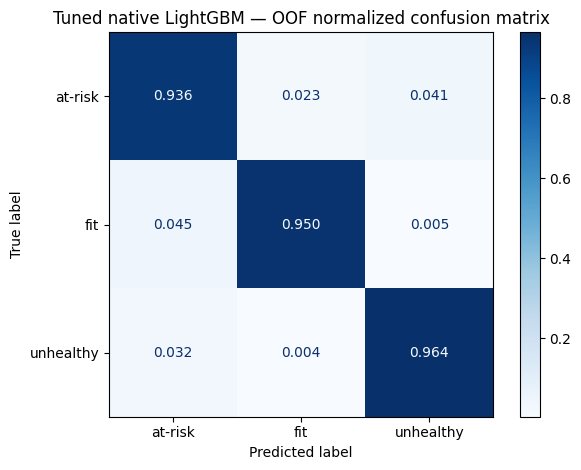

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y,
    oof_raw_prediction,
    display_labels=CLASS_NAMES,
    normalize="true",
    cmap="Blues",
    values_format=".3f",
)
plt.title("Tuned native LightGBM — OOF normalized confusion matrix")
plt.tight_layout()
plt.show()


## 8. Optional differential-evolution threshold test

DE is tested only after the base model is strong. It learns three global class multipliers on half of the OOF rows and is evaluated on the untouched half. Keep it only if the evaluation gain is meaningful and stable.


In [19]:
calibration_idx, de_evaluation_idx = train_test_split(
    np.arange(len(y)),
    test_size=0.50,
    stratify=y,
    random_state=RANDOM_STATE + 100,
)


def apply_probability_weights(probabilities, weights):
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.mean()
    adjusted = probabilities * weights[None, :]
    return adjusted / adjusted.sum(axis=1, keepdims=True)


def optimize_probability_weights(probabilities, y_true, seed=RANDOM_STATE):
    def loss(log_weights):
        weights = np.exp(log_weights)
        prediction = apply_probability_weights(probabilities, weights).argmax(axis=1)
        return -balanced_accuracy_score(y_true, prediction)

    result = differential_evolution(
        loss,
        bounds=[(-1.5, 1.5)] * N_CLASSES,
        strategy="best1bin",
        maxiter=80,
        popsize=15,
        tol=1e-7,
        polish=True,
        seed=seed,
        workers=1,
        updating="immediate",
    )
    weights = np.exp(result.x)
    return weights / weights.mean(), result


calibration_weights, de_result = optimize_probability_weights(
    oof_probs[calibration_idx],
    y[calibration_idx],
)

raw_eval_prediction = oof_probs[de_evaluation_idx].argmax(axis=1)
adjusted_eval_probs = apply_probability_weights(
    oof_probs[de_evaluation_idx],
    calibration_weights,
)
adjusted_eval_prediction = adjusted_eval_probs.argmax(axis=1)

de_comparison = pd.DataFrame([
    {
        "variant": "raw",
        "balanced_accuracy": balanced_accuracy_score(
            y[de_evaluation_idx],
            raw_eval_prediction,
        ),
    },
    {
        "variant": "DE adjusted",
        "balanced_accuracy": balanced_accuracy_score(
            y[de_evaluation_idx],
            adjusted_eval_prediction,
        ),
    },
])

print("Calibration weights:", dict(zip(CLASS_NAMES, calibration_weights.round(5))))
display(de_comparison.style.format({"balanced_accuracy": "{:.6f}"}))

de_gain = (
    de_comparison.loc[de_comparison["variant"].eq("DE adjusted"), "balanced_accuracy"].iloc[0]
    - de_comparison.loc[de_comparison["variant"].eq("raw"), "balanced_accuracy"].iloc[0]
)
USE_DE_FOR_SUBMISSION = de_gain >= 0.0002
print(f"Untouched evaluation gain: {de_gain:+.6f}")
print("Use DE for the primary submission:", USE_DE_FOR_SUBMISSION)


Calibration weights: {'at-risk': np.float64(0.94194), 'fit': np.float64(1.06309), 'unhealthy': np.float64(0.99497)}


,variant,balanced_accuracy
0,raw,0.948897
1,DE adjusted,0.948936


Untouched evaluation gain: +0.000039
Use DE for the primary submission: False


## 9. Final fit and submissions

The raw submission is always saved. A DE-adjusted submission is also saved for comparison, but the raw version remains primary unless the untouched OOF evaluation gain is at least 0.0002.


In [20]:
final_model = make_tuned_model()
full_train_weight = compute_sample_weight(class_weight="balanced", y=y)
final_model.fit(
    X,
    y,
    sample_weight=full_train_weight,
    categorical_feature=categorical_features,
)
test_probs = final_model.predict_proba(X_test)

raw_submission = sample_submission.copy()
raw_submission[TARGET] = label_encoder.inverse_transform(test_probs.argmax(axis=1))
raw_path = SUBMISSION_DIR / "lightgbm_native_optuna_raw.csv"
raw_submission.to_csv(raw_path, index=False)

# Fit production DE weights on all OOF rows only after its honest evaluation.
final_de_weights, _ = optimize_probability_weights(
    oof_probs,
    y,
    seed=RANDOM_STATE + 101,
)
adjusted_test_probs = apply_probability_weights(test_probs, final_de_weights)
adjusted_submission = sample_submission.copy()
adjusted_submission[TARGET] = label_encoder.inverse_transform(
    adjusted_test_probs.argmax(axis=1)
)
adjusted_path = SUBMISSION_DIR / "lightgbm_native_optuna_de_adjusted.csv"
adjusted_submission.to_csv(adjusted_path, index=False)

primary_path = adjusted_path if USE_DE_FOR_SUBMISSION else raw_path
print("Raw submission:", raw_path)
print(raw_submission[TARGET].value_counts(normalize=True).round(4))
print("\nDE-adjusted submission:", adjusted_path)
print(adjusted_submission[TARGET].value_counts(normalize=True).round(4))
print("\nRecommended primary submission:", primary_path)


Raw submission: ..\submissions\lightgbm_native_optuna_raw.csv
health_condition
at-risk      0.810
unhealthy    0.116
fit          0.074
Name: proportion, dtype: float64

DE-adjusted submission: ..\submissions\lightgbm_native_optuna_de_adjusted.csv
health_condition
at-risk      0.8091
unhealthy    0.1166
fit          0.0743
Name: proportion, dtype: float64

Recommended primary submission: ..\submissions\lightgbm_native_optuna_raw.csv


## 10. Interpretation checklist

- The fixed baseline should recover approximately the earlier 0.95 balanced accuracy result.
- HPO should be judged by both its fixed holdout result and the subsequent OOF result.
- A tiny DE gain is likely validation noise; the notebook requires at least `+0.0002` on untouched rows before recommending it.
- The SQLite study can be resumed by increasing `N_TRIALS` and rerunning the study cell.